In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
import os
os.chdir('/Users/lior/DS6021/DS6021_F26/data')

peng = pd.read_csv("penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)
bike = pd.read_csv("bike-sharing-daily.csv", parse_dates=["dteday"])



In [5]:

f3 = "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm"
pm = smf.ols(f3, data=peng).fit()
infl = OLSInfluence(pm)
n_peng = int(pm.nobs)
p_peng = int(pm.df_model)

pdiag = pd.DataFrame({
    "species": peng.species,
    "sex": peng.sex,
    "body_mass_g": peng.body_mass_g,
    "predicted": pm.fittedvalues,
    "student_resid": infl.resid_studentized_external,
    "leverage": infl.hat_matrix_diag,
    "cooks_d": infl.cooks_distance[0],
})
pdiag.head(10)

,species,sex,body_mass_g,predicted,student_resid,leverage,cooks_d
0,Adelie,male,3750.0,3211.617868,1.376420,0.008831,0.004209
1,Adelie,female,3800.0,3438.564312,0.921907,0.007306,0.001564
2,Adelie,female,3250.0,3906.346483,-1.676699,0.004599,0.003230
3,Adelie,female,3450.0,3816.889879,-0.938715,0.013330,0.002977
4,Adelie,male,3650.0,3702.967340,-0.135413,0.014287,0.000067
5,Adelie,female,3625.0,3192.740924,1.104655,0.009992,0.003077
6,Adelie,male,4675.0,3933.847733,1.902148,0.011451,0.010398
7,Adelie,NaN,3475.0,3782.009706,-0.786136,0.015675,0.002463
8,Adelie,NaN,4250.0,3706.184442,1.391234,0.010026,0.004887
9,Adelie,NaN,3300.0,3425.474357,-0.319884,0.008505,0.000220


In [6]:
#b - used claude for this part since i was a bit confused on how to format everything

lev_cut = 2 *(p_peng + 1)/ n_peng
cook_cut = 4 / n_peng
print("n =", n_peng, " p =", p_peng)
print("studentized residual cutoff: |r| > 3")
print("leverage cutoff 2(p+1)/n =", round(lev_cut, 4))
print("Cook's D cutoff 4/n      =", round(cook_cut, 4))

pdiag["outlier"] = pdiag.student_resid.abs() > 3
pdiag["high_lev"] = pdiag.leverage > lev_cut
pdiag["influential"] = pdiag.cooks_d > cook_cut

print(pdiag[["outlier", "high_lev", "influential"]].sum())
print("exceed all three:", (pdiag.outlier & pdiag.high_lev & pdiag.influential).sum())

no_sex = pdiag[pdiag.sex.isna()]
print(no_sex[["species", "body_mass_g", "predicted", "student_resid", "leverage", "cooks_d"]].round(4))
print("flagged among the 9:", no_sex[["outlier", "high_lev", "influential"]].sum().to_dict())
print("their max |resid|, leverage, Cook's D:",
      round(no_sex.student_resid.abs().max(), 3), round(no_sex.leverage.max(), 4), round(no_sex.cooks_d.max(), 5))

print(pdiag[pdiag.outlier][["species", "sex", "body_mass_g", "predicted", "student_resid", "leverage", "cooks_d"]].round(4))
flagged = pdiag[pdiag.outlier | pdiag.high_lev | pdiag.influential]
print("all penguins:", pdiag.species.value_counts(normalize=True).round(2).to_dict())
print("flagged (n=" + str(len(flagged)) + "):", flagged.species.value_counts(normalize=True).round(2).to_dict())

n = 342  p = 3
studentized residual cutoff: |r| > 3
leverage cutoff 2(p+1)/n = 0.0234
Cook's D cutoff 4/n      = 0.0117
outlier         1
high_lev       10
influential    13
dtype: int64
exceed all three: 0
    species  body_mass_g  predicted  student_resid  leverage  cooks_d
7    Adelie       3475.0  3782.0097        -0.7861    0.0157   0.0025
8    Adelie       4250.0  3706.1844         1.3912    0.0100   0.0049
9    Adelie       3300.0  3425.4744        -0.3199    0.0085   0.0002
10   Adelie       3700.0  3127.8689         1.4658    0.0122   0.0066
46   Adelie       2975.0  3108.4304        -0.3405    0.0102   0.0003
177  Gentoo       4100.0  4905.2965        -2.0675    0.0102   0.0109
217  Gentoo       4650.0  4813.8381        -0.4178    0.0087   0.0004
255  Gentoo       4725.0  4906.9248        -0.4646    0.0115   0.0006
267  Gentoo       4875.0  4983.6351        -0.2770    0.0089   0.0002
flagged among the 9: {'outlier': 0, 'high_lev': 0, 'influential': 0}
their max |resid|, lever

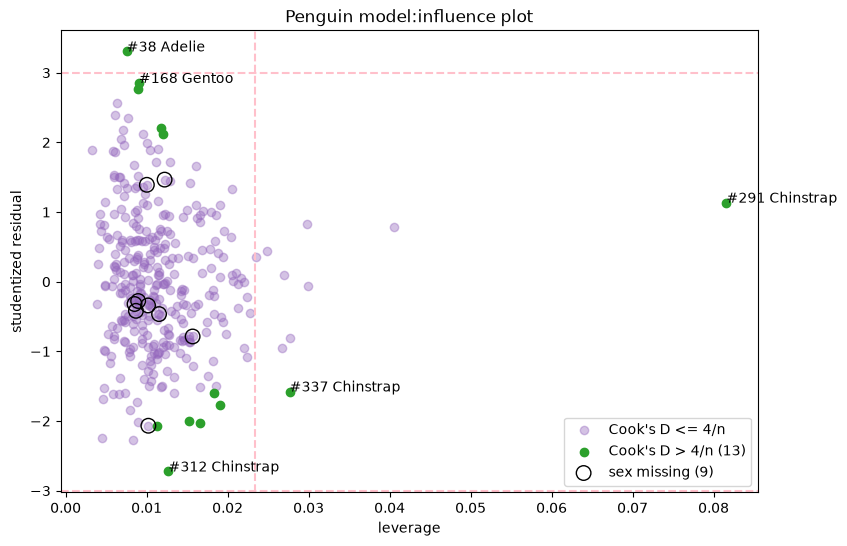

In [9]:
is_infl = pdiag.cooks_d > cook_cut
no_sex_mask = pdiag.sex.isna()

plt.figure(figsize=(9, 6))
plt.scatter(pdiag.leverage[~is_infl], pdiag.student_resid[~is_infl], alpha=0.4, color="tab:purple", label="Cook's D <= 4/n")
plt.scatter(pdiag.leverage[is_infl], pdiag.student_resid[is_infl], color="tab:green", label="Cook's D > 4/n (13)")
plt.scatter(pdiag.leverage[no_sex_mask], pdiag.student_resid[no_sex_mask], s=110,
            facecolors="none", edgecolors="black", label="sex missing (9)")

plt.axhline(3, color="pink", ls="--")
plt.axhline(-3, color="pink", ls="--")
plt.axvline(lev_cut, color="pink", ls="--")
for i, row in pdiag.nlargest(5, "cooks_d").iterrows():
    plt.annotate(f"#{i} {row.species}", (row.leverage, row.student_resid))
plt.xlabel("leverage")
plt.ylabel("studentized residual")
plt.title("Penguin model:influence plot")
plt.legend()
plt.show()

b. the penguins exceed all three and the outlier on row 38 has a low leverage and a moderate cooks d on 0.020. none of the missing sex penguins exceed the cuttoffs the largest residual is about 2.07 and all of the leverages are lower than 0.02.

c. it supports it because in part 2, dropping the penguins didnt change the values at all and since none of the 9 are outliers, removing them doesnt really move the fit much, so i would keep my conclusion the same.

d. most of the pengons sit inside the box and a small leverage with a big cook d value happens twice. row 291 has the highest leverate of 0.082 and is way past the cutoff and has the largest cook d of about 0.029. 

In [ ]:
#help from claude with cleaning and formatting
BF = "cnt ~ temp + hum + windspeed + C(season) + C(weathersit)"
bm = smf.ols(BF, data=bike).fit()
binfl = OLSInfluence(bm)
n_bike = int(bm.nobs)
p_bike = int(bm.df_model)
bdiag = pd.DataFrame({
    "date": bike.dteday,
    "cnt": bike.cnt,
    "fitted": bm.fittedvalues,
    "student_resid": binfl.resid_studentized_external,
    "leverage": binfl.hat_matrix_diag,
    "cooks_d": binfl.cooks_distance[0],
})
bdiag["cooks_rank"] = bdiag.cooks_d.rank(ascending=False)

lev_cut_b = 2 * (p_bike + 1) / n_bike
cook_cut_b = 4 / n_bike
print("n =", n_bike, " p =", p_bike, " leverage cutoff =", round(lev_cut_b, 4), " Cook's D cutoff =", round(cook_cut_b, 4))
print("outliers:", (bdiag.student_resid.abs() > 3).sum(),
      "| high leverage:", (bdiag.leverage > lev_cut_b).sum(),
      "| influential:", (bdiag.cooks_d > cook_cut_b).sum())
print("days exceeding all three:",
      ((bdiag.student_resid.abs() > 3) & (bdiag.leverage > lev_cut_b) & (bdiag.cooks_d > cook_cut_b)).sum())
days = bdiag[(bdiag.date == "2012-03-17") | (bdiag.date == "2012-10-29")].copy()
days["outlier"] = days.student_resid.abs() > 3
days["high_lev"] = days.leverage > lev_cut_b
days["influential"] = days.cooks_d > cook_cut_b
print(days.to_string(index=False))

print(bike[(bike.dteday == "2012-03-17") | (bike.dteday == "2012-10-29")]
      [["dteday", "weekday", "season", "weathersit", "temp", "hum", "windspeed", "casual", "registered", "cnt"]])
print("days per weathersit:", bike.weathersit.value_counts().sort_index().to_dict())
print(bike[["temp", "hum", "windspeed", "cnt"]].describe().loc[["mean", "min", "max"]].round(3))

n = 731  p = 8  leverage cutoff = 0.0246  Cook's D cutoff = 0.0055
outliers: 1 | high leverage: 27 | influential: 24
days exceeding all three: 0
      date  cnt      fitted  student_resid  leverage  cooks_d  cooks_rank  outlier  high_lev  influential
2012-03-17 7836 3740.305424       3.203567  0.016568 0.018968         3.0     True     False         True
2012-10-29   22 1941.204734      -1.522793  0.054691 0.014880         6.0    False      True         True
        dteday  weekday  season  weathersit      temp       hum  windspeed  \
441 2012-03-17        6       1           2  0.514167  0.755833   0.110704   
667 2012-10-29        1       4           3  0.440000  0.880000   0.358200   

     casual  registered   cnt  
441    3155        4681  7836  
667       2          20    22  
days per weathersit: {1: 463, 2: 247, 3: 21}
       temp    hum  windspeed       cnt
mean  0.495  0.628      0.190  4504.349
min   0.059  0.000      0.022    22.000
max   0.862  0.972      0.507  8714.000


In [ ]:
formulas = {
    "in-class model": BF,
    "+ workingday": BF + " + C(workingday)",
    "+ yr": BF + " + C(yr)",
    "temp + hum + windspeed only": "cnt ~ temp + hum + windspeed",
}
for name, f in formulas.items():
    m = smf.ols(f, data=bike).fit()
    inf = OLSInfluence(m)
    n, p = int(m.nobs), int(m.df_model)
    all_three = ((inf.resid_studentized_external > 3) | (inf.resid_studentized_external < -3)) \
                & (inf.hat_matrix_diag > 2 * (p + 1) / n) & (inf.cooks_distance[0] > 4 / n)
    print(name, "->", list(bike.dteday[all_three].dt.strftime("%Y-%m-%d")))

In [13]:
sandy = "2012-10-29"
mar17 = "2012-03-17"
m_all = bm
m_sandy = smf.ols(BF, data=bike[bike.dteday != sandy]).fit()
m_mar17 = smf.ols(BF, data=bike[bike.dteday != mar17]).fit()
m_both = smf.ols(BF, data=bike[(bike.dteday != sandy) & (bike.dteday != mar17)]).fit()

tab = pd.DataFrame({"all data": m_all.params, "drop Sandy": m_sandy.params,
                    "drop 3/17": m_mar17.params, "drop both": m_both.params})
tab["% chg Sandy"] = 100 * (tab["drop Sandy"] - tab["all data"]) / tab["all data"].abs()
tab["% chg 3/17"] = 100 * (tab["drop 3/17"] - tab["all data"]) / tab["all data"].abs()
print(tab.round(2))

print("R2: all", round(m_all.rsquared, 4), "| drop Sandy", round(m_sandy.rsquared, 4),
      "| drop 3/17", round(m_mar17.rsquared, 4), "| drop both", round(m_both.rsquared, 4))

print(pd.DataFrame({"all": m_all.pvalues, "drop Sandy": m_sandy.pvalues, "drop 3/17": m_mar17.pvalues}).round(4))

                    all data  drop Sandy  drop 3/17  drop both  % chg Sandy  \
Intercept            3128.94     3099.87    3125.60    3096.37        -0.93   
C(season)[T.2]        926.97      924.05     980.28     977.41        -0.31   
C(season)[T.3]        471.32      467.54     544.85     541.14        -0.80   
C(season)[T.4]       1496.78     1505.25    1538.74    1547.31         0.57   
C(weathersit)[T.2]   -218.77     -220.74    -237.06    -239.07        -0.90   
C(weathersit)[T.3]  -1902.85    -1815.60   -1916.20   -1828.50         4.59   
temp                 6205.41     6220.06    6085.88    6100.46         0.24   
hum                 -2635.17    -2621.32   -2630.16   -2616.23         0.53   
windspeed           -3330.79    -3258.90   -3237.75   -3165.35         2.16   

                    % chg 3/17  
Intercept                -0.11  
C(season)[T.2]            5.75  
C(season)[T.3]           15.60  
C(season)[T.4]            2.80  
C(weathersit)[T.2]       -8.36  
C(weathersi

removing hurricane sandy doesnt really change anything and every coefficient moves not much in value. the model over predicts it from 22 actual compared to 1,941 fitted but its residual is -1.5 so the coefficients stay around the same.
removing 2012-03-17 causes those coefficients to have a more noticable difference. the weather sit is =2 and r2 rises from 0.5564 to 0.5608. since its winter, the model expects less rentals and inflates the season which results in skewed seasons. 

i wouldnt remove either since hurricane sandy was a super important event and removing it doesnt change much so theres nothing you clean by dropping it. for 2012, theres no reason to drop it either since it just seemed to have been an active day and another model should be ran again so that we could see the difference.

I would report this by just saying how many days the model flagged without saying the dates and then i would reveal it and show the data that shows that dopping either day doesn really change anything and if i did want to remove the day i would also show the results and explain why.